# LSTM Stock Price Prediction

- LSTM -> Long Short Term Memory

## Requirements

In [16]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import root_mean_squared_error
from torch.utils.data import Dataset
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler


## Tutorials
- **(Greg Hogg, 2023)** Video: https://www.youtube.com/watch?v=q_HS4s1L8UI&t=147s
- **(NeuralNine, 2025)** Video: https://www.youtube.com/watch?v=IJ50ew8wi-0

## Load Data

In [17]:
df = pd.read_csv('../data/combined_output.csv')

df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,...,previous_day_high,previous_day_low,previous_day_open,previous_day_volume,day_of_week,numerical_sentiment,mean_sentiment_probability,percent_positive,percent_negative,percent_neutral
0,2026-01-27,672.97,676.8150,664.6600,674.59,13148719,672.407383,676.249169,664.104331,674.026029,...,675.2800,661.2855,665.125,16327378.0,2,0.158879,0.790941,0.299065,0.140187,0.560748
1,2026-01-28,668.73,677.6775,666.1000,674.50,25709600,668.170928,677.110948,665.543127,673.936104,...,676.8150,664.6600,674.590,13148719.0,3,0.170543,0.801010,0.302326,0.131783,0.565891
2,2026-01-29,738.31,744.0000,712.5500,737.43,59852903,737.692758,743.378001,711.954294,736.813493,...,677.6775,666.1000,674.500,25709600.0,4,-0.027027,0.806134,0.209459,0.236486,0.554054
3,2026-01-30,716.50,732.1700,713.5900,727.50,23744573,715.900991,731.557891,712.993424,726.891795,...,744.0000,712.5500,737.430,59852903.0,5,-0.109375,0.837781,0.156250,0.265625,0.578125
4,2026-02-02,706.41,721.3000,703.5201,714.60,14365224,705.819427,720.696978,702.931943,714.002580,...,732.1700,713.5900,727.500,23744573.0,1,-0.076923,0.814024,0.153846,0.230769,0.615385


## Check Device

In [18]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu:1'

device

'cpu:1'

## Lag Features

In [19]:
columns = df.columns

day = 1

df = df.set_index('date')

df['previous_day_numerical_sentiment'] = df['numerical_sentiment'].shift(day)
df['previous_day_mean_sentiment_probability'] = df['mean_sentiment_probability'].shift(day)
df['previous_day_percent_positive'] = df['percent_positive'].shift(day)
df['previous_day_percent_negative'] = df['percent_negative'].shift(day)
df['previous_day_percent_neutral'] = df['percent_neutral'].shift(day)

df = df.drop(columns=['high',
                      'low',
                      'open',
                      'volume',
                      'adjClose',
                      'adjHigh',
                      'adjLow',
                      'adjOpen',
                      'adjVolume',
                      'divCash',
                      'splitFactor',
                      'numerical_sentiment',
                      'mean_sentiment_probability',
                      'percent_positive',
                      'percent_negative',
                      'percent_neutral',])

df.iloc[2]

close                                      7.383100e+02
previous_day_close                         6.687300e+02
previous_day_high                          6.776775e+02
previous_day_low                           6.661000e+02
previous_day_open                          6.745000e+02
previous_day_volume                        2.570960e+07
day_of_week                                4.000000e+00
previous_day_numerical_sentiment           1.705426e-01
previous_day_mean_sentiment_probability    8.010101e-01
previous_day_percent_positive              3.023256e-01
previous_day_percent_negative              1.317829e-01
previous_day_percent_neutral               5.658915e-01
Name: 2026-01-29, dtype: float64

## Plot

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Closing Price')]

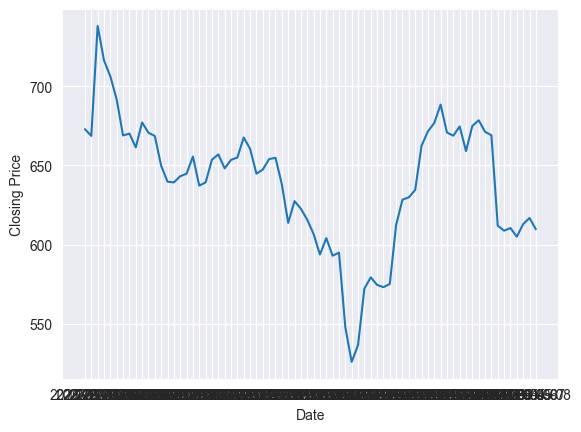

In [20]:
line_graph = sns.lineplot(x='date', y='close', data=df)
line_graph.set(xlabel='Date', ylabel='Closing Price')

## Remove Rows With Nulls

In [21]:
df = df.dropna()

df.to_csv('../data/model_ready.csv')

## Scale Data

In [22]:
scalar_x = StandardScaler()
scalar_y = StandardScaler()

X_df = df.iloc[:,1:]
Y_df = df.iloc[:, [0]]

train_size = int(len(df) * 0.7)

X_train_df_as_numpy = scalar_x.fit_transform(X_df[:train_size]) # Fit to training data
X_test_df_as_numpy = scalar_x.transform(X_df[train_size:])
Y_train_df_as_numpy = scalar_y.fit_transform(Y_df[:train_size]) # Don't fit to test data as it will cause data leakage
Y_test_df_as_numpy = scalar_y.transform(Y_df[train_size:])


X_train_df_as_numpy.shape

(49, 11)

## Split Data Train/Test

In [23]:
X_train = X_train_df_as_numpy.reshape((-1, 11, 1))
Y_train = Y_train_df_as_numpy.reshape((-1, 1))

X_test = X_test_df_as_numpy.reshape((-1, 11, 1))
Y_test = Y_test_df_as_numpy.reshape((-1, 1))

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((49, 11, 1), (49, 1), (22, 11, 1), (22, 1))

## Convert To Tensors

In [24]:
X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

(torch.Size([49, 11, 1]),
 torch.Size([49, 1]),
 torch.Size([22, 11, 1]),
 torch.Size([22, 1]))

## Dataset Class

In [25]:
class StockDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [26]:
train_dataset = StockDataset(X_train, Y_train)
test_dataset = StockDataset(X_test, Y_test)

train_dataset.__len__()

49

## Dataloaders

In [27]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
)

train_dataloader

In [28]:
for _, batch in enumerate(train_dataloader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)


torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([1, 11, 1]) torch.Size([1, 1])


## Define Neural Network

In [29]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [30]:
model = Net(1, 32, 4, 1)
model.to(device)
model

Net(
  (lstm): LSTM(1, 32, num_layers=4, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

## Training Loop

In [31]:
lr = 1e-3
num_epochs = 500
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_function(output, Y_train)

    if epoch % 25 == 0:
        # Every 25 epochs
        print(epoch, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



0 1.0069935321807861
25 0.8010615706443787
50 0.23859527707099915
75 0.20618154108524323
100 0.1839950978755951
125 0.1671685427427292
150 0.154682919383049
175 0.14937914907932281
200 0.13867506384849548
225 0.13381832838058472
250 0.12813714146614075
275 0.11532502621412277
300 0.09340149164199829
325 0.08808212727308273
350 0.08512888848781586
375 0.08019062876701355
400 0.07687396556138992
425 0.0815555527806282
450 0.07609693706035614
475 0.0731138214468956


## Testing

In [32]:
model.eval()

test_output_prediction = model(X_test)

train_output_prediction = scalar_y.inverse_transform(output.detach().cpu().numpy())
train_actual = scalar_y.inverse_transform(Y_train.detach().cpu().numpy())
test_output_prediction = scalar_y.inverse_transform(test_output_prediction.detach().cpu().numpy())
test_actual = scalar_y.inverse_transform(Y_test.detach().cpu().numpy())

train_output_prediction.shape, train_actual.shape, test_output_prediction.shape, test_actual.shape

((49, 1), (49, 1), (22, 1), (22, 1))

In [33]:
train_rmse = root_mean_squared_error(train_actual, train_output_prediction)
test_rmse = root_mean_squared_error(test_actual, test_output_prediction)


In [34]:
{'train_rmse' :train_rmse, 'test_rmse':test_rmse}

{'train_rmse': 12.834521293640137, 'test_rmse': 18.377151489257812}

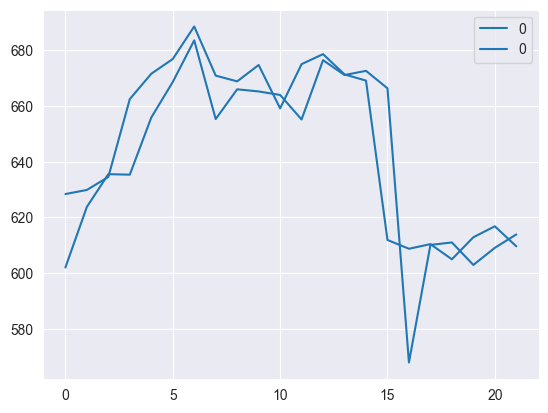

In [35]:


actual_line = sns.lineplot(test_actual)
predicted_line = sns.lineplot(test_output_prediction)

